<a href="https://colab.research.google.com/github/alenachuklina/global-economic-risk-monitor/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Economic Risk Monitor

This notebook explores GDP data using the World Bank API.

Goals of this notebook:
- Download GDP data
- Inspect the dataset
- Reshape the data for analysis
- Visualize GDP trends for selected countries

## 1. Import libraries



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import zipfile
import os

## 2. Download data from the World Bank API

The World Bank provides open macroeconomic datasets.  


In [2]:
url = "https://api.worldbank.org/v2/country/all/indicator/NY.GDP.MKTP.CD?downloadformat=csv"

response = requests.get(url)

with open("gdp_data.zip", "wb") as f:
    f.write(response.content)

In [3]:
url = "https://api.worldbank.org/v2/country/all/indicator/FP.CPI.TOTL.ZG?downloadformat=csv"

response = requests.get(url)

with open("inflation_data.zip", "wb") as f:
    f.write(response.content)

## 3. Extract the dataset

The API returns a ZIP archive.  
We extract the files to access the CSV dataset.

In [4]:
with zipfile.ZipFile("gdp_data.zip", "r") as zip_ref:
    zip_ref.extractall("gdp_data")

os.listdir("gdp_data")

['API_NY.GDP.MKTP.CD_DS2_EN_csv_v2_10142.csv',
 'Metadata_Country_API_NY.GDP.MKTP.CD_DS2_EN_csv_v2_10142.csv',
 'Metadata_Indicator_API_NY.GDP.MKTP.CD_DS2_EN_csv_v2_10142.csv']

In [5]:
with zipfile.ZipFile("inflation_data.zip", "r") as zip_ref:
    zip_ref.extractall("inflation_data")

os.listdir("inflation_data")

['API_FP.CPI.TOTL.ZG_DS2_EN_csv_v2_15811.csv',
 'Metadata_Country_API_FP.CPI.TOTL.ZG_DS2_EN_csv_v2_15811.csv',
 'Metadata_Indicator_API_FP.CPI.TOTL.ZG_DS2_EN_csv_v2_15811.csv']

## 4. Load the dataset into pandas

We skip the first rows because they contain metadata.

In [6]:
df_gdp = pd.read_csv("gdp_data/API_NY.GDP.MKTP.CD_DS2_EN_csv_v2_10142.csv", skiprows=4)
df_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3.092428e+09,3.276188e+09,3.346623e+09,2.471419e+09,2.880903e+09,3.324034e+09,3.834730e+09,4.265651e+09,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.420569e+10,2.495889e+10,2.707323e+10,3.176914e+10,3.027955e+10,3.380618e+10,...,9.780765e+11,1.020956e+12,1.018715e+12,9.386076e+11,1.114145e+12,1.228968e+12,1.179359e+12,1.242694e+12,NaN,NaN
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426000e+10,1.449724e+10,1.715223e+10,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.190481e+10,1.270772e+10,1.363059e+10,1.446891e+10,1.580356e+10,1.692088e+10,...,6.940513e+11,7.778403e+11,1.026996e+12,9.637847e+11,1.026651e+12,1.063649e+12,9.382384e+11,7.363850e+11,NaN,NaN
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,8.437694e+10,8.951279e+10,8.073443e+10,5.885246e+10,7.955954e+10,1.312122e+11,1.071677e+11,1.009989e+11,NaN,NaN


In [7]:
df_inf = pd.read_csv("inflation_data/API_FP.CPI.TOTL.ZG_DS2_EN_csv_v2_15811.csv", skiprows=4)
df_inf.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.489789,NaN,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,NaN,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,NaN,NaN


## 5. Explore the dataset structure


In [8]:
df_gdp.info()
df_gdp.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            151 non-null    float64
 5   1961            154 non-null    float64
 6   1962            156 non-null    float64
 7   1963            156 non-null    float64
 8   1964            156 non-null    float64
 9   1965            162 non-null    float64
 10  1966            163 non-null    float64
 11  1967            167 non-null    float64
 12  1968            168 non-null    float64
 13  1969            168 non-null    float64
 14  1970            190 non-null    float64
 15  1971            191 non-null    float64
 16  1972            191 non-null    float64
 17  1973            191 non-null    flo

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='object')

In [9]:
df_inf.info()
df_inf.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            70 non-null     float64
 5   1961            72 non-null     float64
 6   1962            74 non-null     float64
 7   1963            74 non-null     float64
 8   1964            79 non-null     float64
 9   1965            86 non-null     float64
 10  1966            93 non-null     float64
 11  1967            100 non-null    float64
 12  1968            101 non-null    float64
 13  1969            102 non-null    float64
 14  1970            108 non-null    float64
 15  1971            112 non-null    float64
 16  1972            114 non-null    float64
 17  1973            117 non-null    flo

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='object')

In [10]:
#cn = df['Country Name']
#cn
#spain = cn[cn == "Spain"]
#spain


## 6. Inspect GDP for a single country

To understand the data better, we examine GDP values for Spain.

In [11]:
spain_gdp = df_gdp[df_gdp['Country Name'] == 'Spain']
spain_gdp

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
70,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1.242451e+10,1.423813e+10,1.660963e+10,1.963171e+10,2.196688e+10,2.547962e+10,...,1.321754e+12,1.431643e+12,1.403496e+12,1.289784e+12,1.461245e+12,1.448851e+12,1.619482e+12,1.725672e+12,NaN,NaN


In [12]:
spain_years_gdp = spain_gdp.iloc[:, 4:]
spain_years_gdp

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
70,1.242451e+10,1.423813e+10,1.660963e+10,1.963171e+10,2.196688e+10,2.547962e+10,2.955944e+10,3.257091e+10,3.239433e+10,3.709069e+10,...,1.321754e+12,1.431643e+12,1.403496e+12,1.289784e+12,1.461245e+12,1.448851e+12,1.619482e+12,1.725672e+12,NaN,NaN


In [13]:
germany_inf= df_inf[df_inf['Country Name'] == 'Germany']
germany_inf

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
55,Germany,DEU,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1.536612,2.293695,2.84327,2.96696,2.335736,3.242319,...,1.509495,1.732169,1.44566,0.144878,3.066667,6.872574,5.946437,2.256498,NaN,NaN


In [14]:
germany_years_inf = germany_inf.iloc[:, 4:]
germany_years_inf

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
55,1.536612,2.293695,2.84327,2.96696,2.335736,3.242319,3.53306,1.79605,1.470289,1.912678,...,1.509495,1.732169,1.44566,0.144878,3.066667,6.872574,5.946437,2.256498,NaN,NaN


## 7. Visualize GDP over time

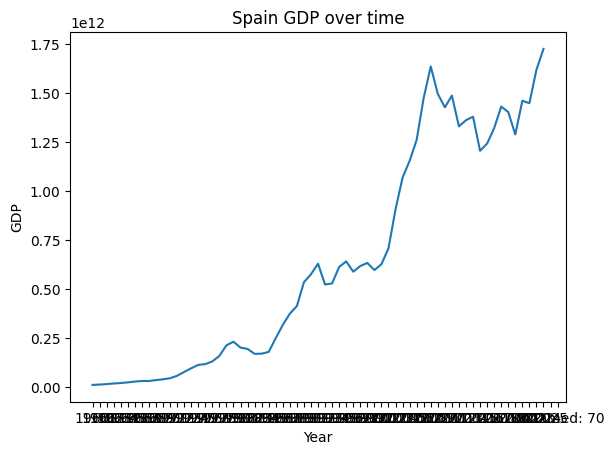

In [15]:
years = spain_years_gdp.columns
values = spain_years_gdp.values.flatten()

plt.plot(years, values)
plt.title("Spain GDP over time")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.show()

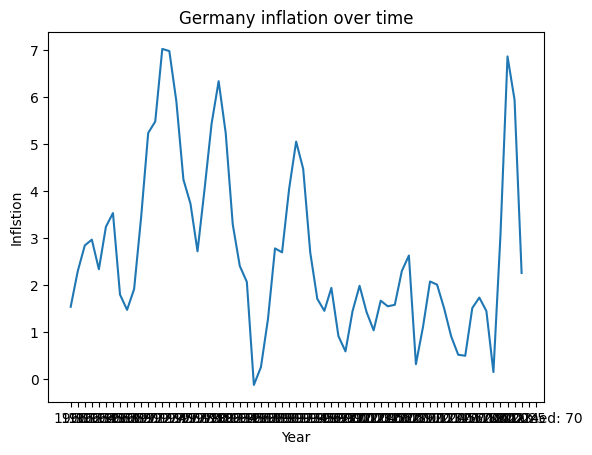

In [16]:
years = germany_years_inf.columns
values = germany_years_inf.values.flatten()

plt.plot(years, values)
plt.title("Germany inflation over time")
plt.xlabel("Year")
plt.ylabel("Inflstion")
plt.show()

## 8. Reshape the dataset and drop unnamed


In [17]:
df_gdp = df_gdp.drop(columns=["2025", "Unnamed: 70"])

In [18]:
df_long_gdp = df_gdp.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="year",
    value_name="GDP"
)

df_long_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,year,GDP
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,1960,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,1960,2.420569e+10
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,1960,NaN
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1960,1.190481e+10
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,1960,NaN


In [19]:
df_inf = df_inf.drop(columns=["2025", "Unnamed: 70"])

In [20]:
df_long_inf = df_inf.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="year",
    value_name="Inflation"
)

df_long_inf.head()

,Country Name,Country Code,Indicator Name,Indicator Code,year,Inflation
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN


## 9. Data cleaning

We remove missing values and convert the year column into integers.

In [21]:
df_long_gdp = df_long_gdp.dropna()
df_long_gdp["year"] = df_long_gdp["year"].astype(int)

In [22]:
spain_gdp = df_long_gdp[df_long_gdp["Country Name"] == "Spain"]
spain_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,year,GDP
70,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1960,1.242451e+10
336,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1961,1.423813e+10
602,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1962,1.660963e+10
868,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1963,1.963171e+10
1134,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1964,2.196688e+10


In [23]:
df_long_inf = df_long_inf.dropna()
df_long_inf["year"] = df_long_inf["year"].astype(int)

In [24]:
germany_inf = df_long_inf[df_long_inf["Country Name"] == "Germany"]
germany_inf.head()

,Country Name,Country Code,Indicator Name,Indicator Code,year,Inflation
55,Germany,DEU,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,1.536612
321,Germany,DEU,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1961,2.293695
587,Germany,DEU,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1962,2.843270
853,Germany,DEU,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1963,2.966960
1119,Germany,DEU,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1964,2.335736


## 10. Final GDP visualization

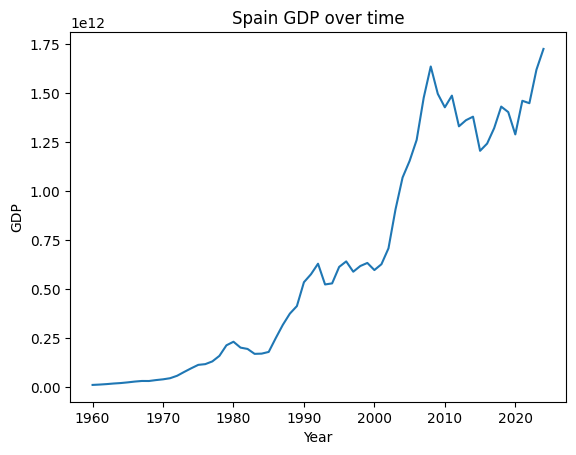

In [26]:
plt.plot(spain_gdp["year"], spain_gdp["GDP"])
plt.title("Spain GDP over time")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.show()


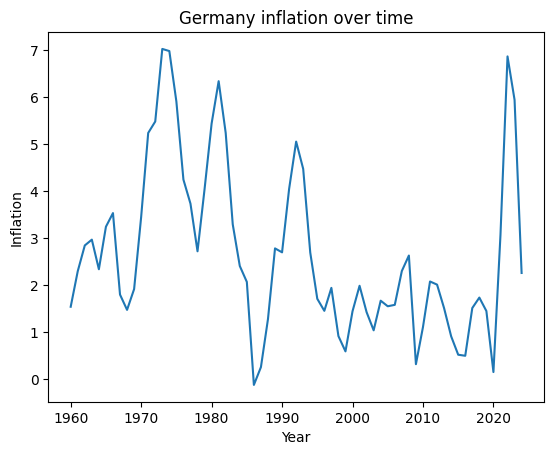

In [27]:
plt.plot(germany_inf["year"], germany_inf["Inflation"])
plt.title("Germany inflation over time")
plt.xlabel("Year")
plt.ylabel("Inflation")
plt.show()


## GDP analytics for 4 countries

In [28]:
countries = ["Spain", "Germany", "France", "Italy"]
df_compare_gdp = df_long_gdp[df_long_gdp["Country Name"].isin(countries)]
df_compare_gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,year,GDP
55,Germany,DEU,GDP (current US$),NY.GDP.MKTP.CD,1960,8.461985e+10
70,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1960,1.242451e+10
77,France,FRA,GDP (current US$),NY.GDP.MKTP.CD,1960,6.195909e+10
116,Italy,ITA,GDP (current US$),NY.GDP.MKTP.CD,1960,4.201242e+10
321,Germany,DEU,GDP (current US$),NY.GDP.MKTP.CD,1961,9.655820e+10


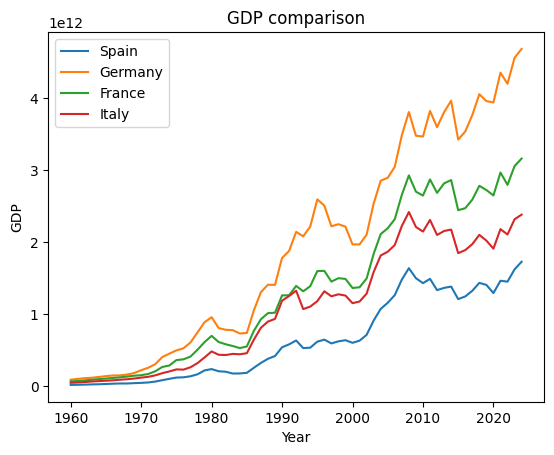

In [29]:
for country in countries:
    country_data = df_compare_gdp[df_compare_gdp["Country Name"] == country]
    plt.plot(country_data["year"], country_data["GDP"], label=country)

plt.title("GDP comparison")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.legend()
plt.show()

## GDP growth

In [30]:
df_long_gdp["GDP_growth"] = df_long_gdp.groupby("Country Name")["GDP"].pct_change() * 100

In [31]:
spain_gdp = df_long_gdp[df_long_gdp["Country Name"] == "Spain"]
spain_gdp.head(20)

,Country Name,Country Code,Indicator Name,Indicator Code,year,GDP,GDP_growth
70,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1960,1.242451e+10,NaN
336,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1961,1.423813e+10,14.597052
602,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1962,1.660963e+10,16.656026
868,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1963,1.963171e+10,18.194755
1134,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1964,2.196688e+10,11.894841
1400,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1965,2.547962e+10,15.991093
1666,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1966,2.955944e+10,16.012078
1932,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1967,3.257091e+10,10.187844
2198,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1968,3.239433e+10,-0.542137
2464,Spain,ESP,GDP (current US$),NY.GDP.MKTP.CD,1969,3.709069e+10,14.497486


##Merge GDP and Inflation Visualization

In [33]:
df_merged = df_long_gdp.merge(
    df_long_inf,
    on=["Country Name", "year"]
)

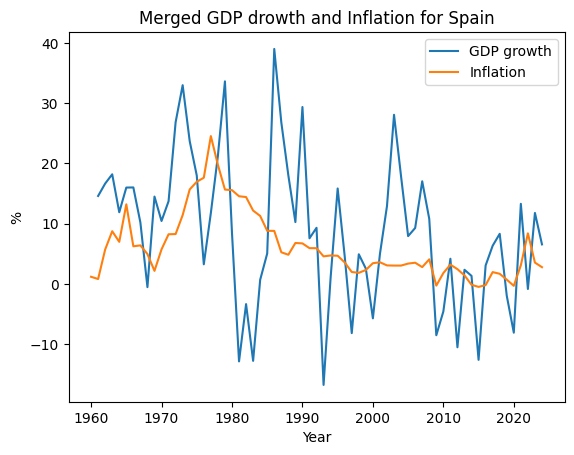

In [38]:
spain = df_merged[df_merged["Country Name"] == "Spain"]

plt.plot(spain["year"], spain["GDP_growth"], label="GDP growth")
plt.plot(spain["year"], spain["Inflation"], label="Inflation")


plt.title("Merged GDP drowth and Inflation for Spain")
plt.xlabel("Year")
plt.ylabel("%")
plt.legend()
plt.show()